<ipython-input-4-dbc0f7e5d5d4>:11: RuntimeWarning: overflow encountered in double_scalars
  return -1000*y + 3000 - 2000*np.exp(-t)
<ipython-input-4-dbc0f7e5d5d4>:28: RuntimeWarning: invalid value encountered in double_scalars
  y[i+1] = y[i] + h * f(t[i], y[i])


h = 0.1
  steps = 300
  max error = nan
h = 0.01
  steps = 3,000
  max error = nan
h = 0.001
  steps = 30,000
  max error = 3.671427e-01
h = 1e-05
  steps = 2,999,999
  max error = 1.842145e-03
h = 1e-07
  Would require 300,000,000 steps
  Too many steps to run, skipped



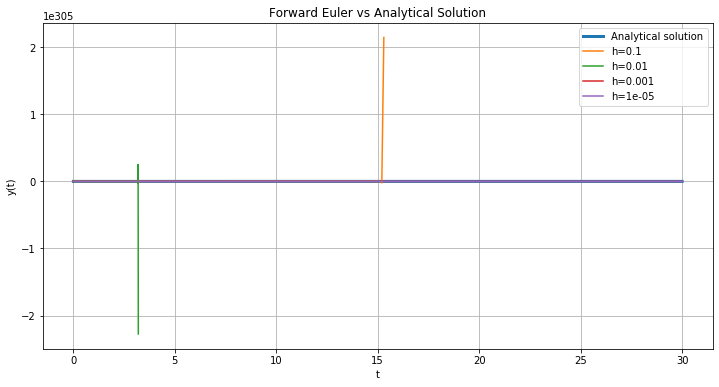

In [4]:
# Mrinal Pradhan
# Challenge 19
# Code this using Euler's Forward, use h = .1, .01, .001, .00001, .0000001 t: 0 to 30

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ODE: y' = -1000y + 3000 - 2000e^(-t)
def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

# Exact solution
def y_exact(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

# Euler Forward
def euler_forward(f, t0, y0, t_end, h):
    n = int((t_end - t0) / h)
    t = np.zeros(n + 1)
    y = np.zeros(n + 1)

    t[0] = t0
    y[0] = y0

    for i in range(n):
        t[i+1] = t[i] + h
        y[i+1] = y[i] + h * f(t[i], y[i])

    return t, y

# Setup
t0 = 0
y0 = 0
t_end = 30

h_values = [0.1, 0.01, 0.001, 0.00001, 0.0000001]

# Analytical solution
t_dense = np.linspace(t0, t_end, 5000)
y_dense = y_exact(t_dense)

# Plot
plt.figure(figsize=(12,6))
plt.plot(t_dense, y_dense, linewidth=3, label="Analytical solution")

for h in h_values:
    n_steps = int((t_end - t0) / h)

    # Skip the impossible one so the program can still run
    if n_steps > 10_000_000:
        print(f"h = {h}")
        print(f"  Would require {n_steps:,} steps")
        print("  Too many steps to run, skipped\n")
        continue

    t_num, y_num = euler_forward(f, t0, y0, t_end, h)
    plt.plot(t_num, y_num, label=f"h={h}")

    y_true = y_exact(t_num)
    max_error = np.max(np.abs(y_num - y_true))

    print(f"h = {h}")
    print(f"  steps = {n_steps:,}")
    print(f"  max error = {max_error:.6e}")
    
plt.title("Forward Euler vs Analytical Solution")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()
